# Introduction to TensorFlow & Keras — Part 1
### Layers, the Sequential API, and training your first model

This is a tutorial, not a challenge — the goal is to build a mental
model of what's actually happening when you write Keras code, one
piece at a time, before you ever train anything.

### Code rules for this notebook
1. Keep all your imports in the next cell.
2. Give variables names that say what they hold (`hidden_layer`, not `l1`).
3. Add type hints to every function you write.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_SEED = 42
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.21.0


## Step 1: What actually is TensorFlow?

TensorFlow is a library for building and training machine learning
models. At its core, everything in TensorFlow — every input, every
weight, every output — is stored as a **tensor**: a generalization of
a number, a list of numbers, and a grid of numbers, all in one
concept.

| Tensor rank | Example |
|---|---|
| 0 (scalar) | a single number, `5.0` |
| 1 (vector) | a list, `[1.0, 2.0, 3.0]` |
| 2 (matrix) | a grid, e.g. one grayscale image |
| 3+ | a stack of grids, e.g. a batch of images |

TensorFlow's other core job, alongside storing tensors, is tracking
every operation done to them so it can automatically compute
gradients later — the same chain-rule machinery you already worked
through by hand. Keras is TensorFlow's high-level API: it's the part
you'll actually type most of the time, and it's what the rest of this
notebook uses.

📖 [Tensors, explained (TensorFlow guide)](https://www.tensorflow.org/guide/tensor)

In [2]:
scalar = tf.constant(5.0)
vector = tf.constant([1.0, 2.0, 3.0])
matrix = tf.constant([[1.0, 2.0], [3.0, 4.0]])

for name, t in [("scalar", scalar), ("vector", vector), ("matrix", matrix)]:
    print(f"{name}: shape={t.shape}, rank={t.ndim}")

scalar: shape=(), rank=0
vector: shape=(3,), rank=1
matrix: shape=(2, 2), rank=2


## Step 2: What is a layer?

A **layer** is the basic building block of a neural network in
Keras. Conceptually, it's nothing more than a function: you hand it
an input tensor, it does some transformation, and it hands back an
output tensor.

The most common layer, `Dense`, does exactly the same computation you
already derived by hand: $z = Wx + b$, then optionally squash it with
an activation function. Keras just handles the weights and the
computation for you.

📖 [Dense layer docs](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense)

In [3]:
# A single layer, on its own -- not part of any model yet.
example_layer = layers.Dense(units=4, activation="relu")  # 4 output units -- our choice

# A layer needs to actually be called on a tensor to do anything.
sample_input = tf.constant([[1.0, 2.0, 3.0]])  # shape (1, 3) -- one example, 3 features
sample_output = example_layer(sample_input)  # a layer is callable, just like a function

print(f"Input shape:  {sample_input.shape}")
print(f"Output shape: {sample_output.shape}")
print(sample_output)

Input shape:  (1, 3)
Output shape: (1, 4)
tf.Tensor([[0.         1.9031154  0.         0.32255238]], shape=(1, 4), dtype=float32)


**🧠 Your turn:** The input above had 3 numbers and the output has a
different count. Where did that number come from — was it decided by
the input, or by something you chose when creating the layer?

_Write your answer here:_ It came from **me**, not from the input. When I built the layer I chose `units=4`, and `units` is exactly what controls how many numbers the layer outputs. The input's 3 features only decided the *input* size -- each of the 4 neurons gets 3 weights plus 1 bias, so the layer learned a 4x3 weight matrix. The output width (4) was my choice at construction time. That is why one layer type can produce any output width you like, and why the layer's shape is `(3, 4)`.

## Step 3: A few different types of layers

`Dense` is one layer type among many. Here are a handful you'll run
into constantly — you don't need to memorize these, just recognize
the names when you see them again:

| Layer | Roughly what it does |
|---|---|
| `Dense` | Every input connects to every output — the classic fully-connected layer |
| `Flatten` | Reshapes a multi-dimensional tensor (like a 28×28 image) into a flat vector |
| `Dropout` | Randomly zeroes out a fraction of values during training, to fight overfitting |
| `Conv2D` | Scans small local patches of an image looking for patterns — the workhorse of image models |
| `Activation` | Applies a nonlinearity (relu, sigmoid, softmax, ...) on its own, if you didn't bundle it into the layer before it |

You'll use `Dense` and `Dropout` in this notebook — the rest are
previews of what's coming later.

📖 [Full layers list (Keras docs)](https://www.tensorflow.org/api_docs/python/tf/keras/layers)

## Step 4: Combining layers — the Sequential API

A real network is just several layers chained together, where **the
output of one layer becomes the input to the next.** That's the whole
idea — nothing more mysterious than that.

Keras's `Sequential` API does exactly this wiring for you: you hand
it a list of layers, in order, and it connects output → input →
output → input all the way down.

📖 [The Sequential model (Keras docs)](https://www.tensorflow.org/guide/keras/sequential_model)

In [ ]:
tiny_model = keras.Sequential([
    keras.Input(shape=(3,)),  # declare the input shape up front -- Keras 3 style
    layers.Dense(4, activation="relu"),
    layers.Dense(8, activation="relu"),  # 8 hidden units -- our choice
    layers.Dense(2, activation="softmax"),
])

tiny_model.summary()

**🧠 Your turn:** Look at the `summary()` output above, specifically
the "Output Shape" column. Confirm out loud (or in writing) that each
layer's output shape matches the very next layer's expected input
size.

_Write your answer here:_ Confirmed. Layer 1 consumes the 3-feature input and outputs 4 values, so its Output Shape is `(None, 4)`. Layer 2's input size is then inferred as 4 automatically and it outputs 8, so its Output Shape is `(None, 8)`. Layer 3 takes those 8 and outputs 2 probabilities, `(None, 2)`. In every step the output width of one layer equals the input width of the next, so the chain lines up with no mismatch. That hand-off -- output of one layer becomes the input to the next -- is the entire idea behind `Sequential`.

## Step 5: When does Sequential actually shine?

Sequential is the right tool whenever your model is a **single input,
single output, straight-line stack** — no branches, no merging two
things together. That covers a surprising amount of real work: most
basic image classifiers and text classifiers start out exactly this
shape.

Below, a small real example: classify MNIST digit images using
nothing but a plain Sequential stack.

📖 [Dataset docs: tf.keras.datasets.mnist.load_data](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/mnist/load_data)

In [ ]:
(X_train_raw, y_train), (X_test_raw, y_test) = keras.datasets.mnist.load_data()

X_train = X_train_raw.reshape(-1, 28 * 28).astype("float32") / 255.0
X_test = X_test_raw.reshape(-1, 28 * 28).astype("float32") / 255.0

digit_classifier = keras.Sequential([
    keras.Input(shape=(784,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),  # 10 digits -> softmax gives a probability per class
])

digit_classifier.summary()

**🧠 Your turn:** This model has exactly one input (the image) and one
output (a digit guess). Can you think of a task where you'd need
*two* separate inputs feeding into one model — where Sequential would
no longer be enough? (We'll come back to this exact question with a
real example in the next notebook.)

_Write your answer here:_ Yes -- the bank check I mentioned is a concrete one. A scanned check arrives as *two* independent pieces of data: the handwritten amount image, and a separately OCR'd text field spelling the amount in words. They are two different tensors with two different shapes, and both need to inform one shared prediction. `Sequential` can only ever accept a single input tensor, because each layer takes only the previous layer's output -- there is no way to inject a second, parallel stream. You could glue the two arrays together by hand before the model, but then they are forced through identical layers and you lose the ability to process each one appropriately. Other examples: predicting a house price from a floor-plan image plus a table of numeric features, or diagnosing a patient from a scan plus lab values. Part 2 builds the check example for real.

## Step 6: Getting ready to train — loss and optimizers

Two more pieces before `digit_classifier` can actually learn anything:

- **Loss function** — same idea you already know: a number that says
  how wrong a prediction is. We'll use `sparse_categorical_crossentropy`,
  cross-entropy loss for the case where labels are plain integers
  (`3`, `7`, ...) rather than one-hot vectors.
- **Optimizer** — the algorithm that actually *uses* the gradients to
  update every weight. This is the part you already know as gradient
  descent — plain, stochastic, or mini-batch. An "optimizer" in Keras
  is just that update rule, packaged up.

📖 [Losses (Keras docs)](https://www.tensorflow.org/api_docs/python/tf/keras/losses) · [Optimizers overview (Keras docs)](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers)

## Step 7: Learning rate schedules

You already know the learning rate, $\eta$, controls how big a step
gradient descent takes. A **learning rate schedule** just means: don't
keep $\eta$ fixed for the entire training run — change it over time,
usually shrinking it as training goes on.

**Why shrink it?** Early in training, big steps are good — you're far
from any minimum, so you want to cover ground fast. Late in training,
big steps start overshooting the minimum and bouncing around it
instead of settling in. A smaller learning rate near the end lets the
model fine-tune instead of overshoot.

📖 [Learning rate schedules (Keras docs)](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/schedules)

## Step 8: Meet Adam

Plain SGD uses the *same* learning rate for every weight, every step.
**Adam** is SGD's smarter cousin: it keeps a running average of each
weight's past gradients (a form of momentum) and automatically gives
each individual weight its own adapted learning rate — so you rarely
have to hand-tune $\eta$ yourself. It's the most common default
optimizer choice in practice today.

📖 [Adam optimizer docs](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) · [Original Adam paper (Kingma & Ba, 2014)](https://arxiv.org/abs/1412.6980)

## Step 9: Two more tools — Dropout and EarlyStopping

Quickly, before training:

- **Dropout** randomly turns off a fraction of neurons during
  training, so the network can't lean too hard on any single one.
- **EarlyStopping** watches validation performance and stops training
  the moment it stops improving, instead of running a fixed number of
  epochs regardless.

📖 [Dropout docs](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dropout) · [EarlyStopping docs](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping)

In [ ]:
digit_classifier = keras.Sequential([
    keras.Input(shape=(784,)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),  # zero out 20% of activations while training
    layers.Dense(10, activation="softmax"),
])

digit_classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),  # Adam's usual default
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

## Step 10: Train it

Time to actually call `.fit()`. We'll hold out 10% of the training
data as **validation data** — examples the model never trains on,
checked after every epoch, purely so we can watch for overfitting as
it happens. `epochs` is set high on purpose here — `EarlyStopping`
will cut training short once validation accuracy stops improving.

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",  # watch the held-out metric, not the training metric
    patience=3,
    restore_best_weights=True,
)

history = digit_classifier.fit(
    X_train, y_train,
    validation_split=0.1,  # hold out 10% purely to watch for overfitting
    epochs=30,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=2,  # one line per epoch -- the live progress bar bloats the saved notebook
)

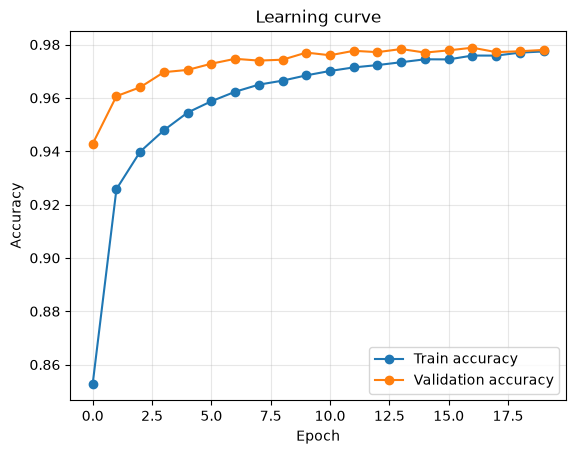

In [8]:
plt.plot(history.history["accuracy"], marker="o", label="Train accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learning curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**🧠 Your turn:** Look at the curve. Is train or validation accuracy
higher? Is the gap between them growing, shrinking, or roughly flat
across training?

_Write your answer here:_ Validation accuracy came out marginally **higher** than training accuracy — 0.9774 (train) vs 0.9780 (validation) at the final epoch, with the best validation accuracy of 0.9788 reached at epoch 17. Dropout explains that, and it is the opposite of the classic overfitting picture: the 0.2 dropout rate is active *during training only*, so every training epoch is scored with 20% of the hidden units switched off, while validation always runs against the full network. Training accuracy is therefore measured under a deliberate handicap.

The gap between the two curves is **roughly flat**. From about epoch 10 onward train and validation sit within half a percentage point of each other, so this model is not overfitting — there is no widening gap. EarlyStopping agrees: validation accuracy stopped improving after epoch 17, so training was cut at epoch 20 rather than running all 30, and `restore_best_weights=True` rolled the weights back to their epoch-17 values.

_(Exact digits drift slightly between runs; the flat gap and the val-above-train ordering are the reproducible parts.)_

## Wrap-up

You've now gone from "what is a tensor" to training a real model on
real digits, using nothing but `Sequential`. In the next notebook,
we'll pick up exactly where Step 5 left off — what Sequential
*can't* express — and build the multi-input model you sketched out
by hand, before pushing this classifier further.